# XGBoost

## Import data

In [5]:
import joblib

In [6]:
folder_path = '../../data/'
X_train = joblib.load(folder_path + 'x_train.joblib')
y_train = joblib.load(folder_path + 'y_train.joblib')
X_val = joblib.load(folder_path + 'x_val.joblib')
y_val = joblib.load(folder_path + 'y_val.joblib')
X_test = joblib.load(folder_path + 'x_test.joblib')
y_test = joblib.load(folder_path + 'y_test.joblib')

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13853 entries, 1335799 to 5086907
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   amount                   13853 non-null  float64
 1   type_CASH_IN             13853 non-null  int64  
 2   type_CASH_OUT            13853 non-null  int64  
 3   type_DEBIT               13853 non-null  int64  
 4   type_PAYMENT             13853 non-null  int64  
 5   type_TRANSFER            13853 non-null  int64  
 6   orig_tx_count_same_step  13853 non-null  int64  
 7   orig_tx_cumcount         13853 non-null  int64  
 8   orig_prev_amount         13853 non-null  float64
 9   orig_amount_ratio        13853 non-null  float64
 10  steps_since_last_tx      13853 non-null  float64
 11  dest_tx_cumcount         13853 non-null  int64  
 12  dest_prev_amount         13853 non-null  float64
 13  dest_amount_ratio        13853 non-null  float64
 14  dest_steps_since_la

## Train XGBoost model

In [1]:
import xgboost as xgb

In [12]:
# 1. Initialize with early_stopping_rounds inside the constructor!
model = xgb.XGBClassifier(
    max_depth=5,              
    learning_rate=0.05,       
    n_estimators=1500,        
    subsample=0.8,            
    colsample_bytree=0.8,     
    objective='binary:logistic',
    eval_metric='aucpr',      
    random_state=42,          
    n_jobs=-1,
    early_stopping_rounds=30  # <--- IT LIVES HERE NOW
)

In [13]:
# 2. Fit the model (Only pass the validation data here)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # The referee is still passed here
    verbose=100
)

[0]	validation_0-aucpr:0.07018
[100]	validation_0-aucpr:0.51086
[171]	validation_0-aucpr:0.51552


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,30
,enable_categorical,False
,eval_metric,'aucpr'


## Evaluate the performance

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, ConfusionMatrixDisplay

In [17]:
y_pred = model.predict(X_test)

In [19]:
print(confusion_matrix(y_test, y_pred))

[[619881  12617]
 [   620   3144]]


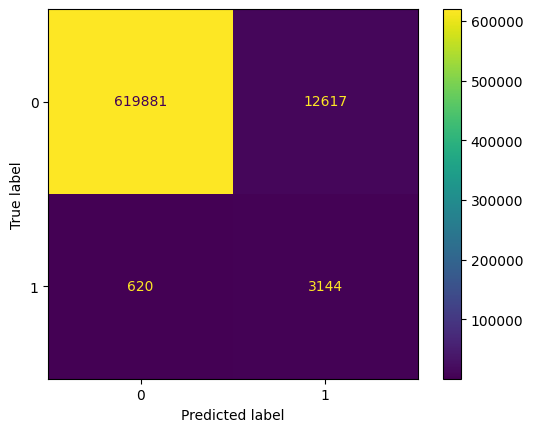

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [21]:
f2_score = fbeta_score(y_test, y_pred, beta=2)
print(f"F2-Score: {f2_score:.4f}")

F2-Score: 0.5101


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    632498
           1       0.20      0.84      0.32      3764

    accuracy                           0.98    636262
   macro avg       0.60      0.91      0.66    636262
weighted avg       0.99      0.98      0.99    636262



In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

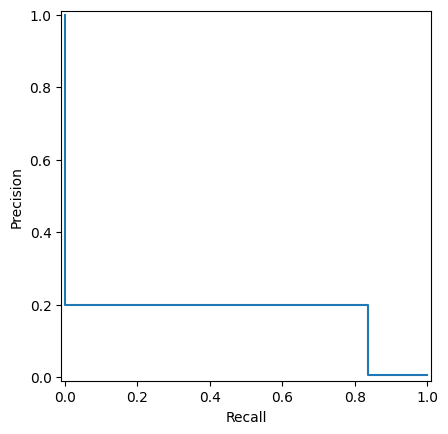

In [29]:
precision, recall, _ = precision_recall_curve(y_test, y_pred)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.show()

In [2]:
model.save_model('../../model/xgboost.json')

NameError: name 'model' is not defined

In [3]:
model = xgb.XGBClassifier()

In [4]:
model.load_model('../../model/xgboost.json')
model.feature_names_in_

array(['amount', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER', 'orig_tx_count_same_step',
       'orig_tx_cumcount', 'orig_prev_amount', 'orig_amount_ratio',
       'steps_since_last_tx', 'dest_tx_cumcount', 'dest_prev_amount',
       'dest_amount_ratio', 'dest_steps_since_last', 'pair_tx_cumcount',
       'is_new_dest', 'pair_total_amount', 'hour_of_day', 'day',
       'is_night'], dtype='<U23')

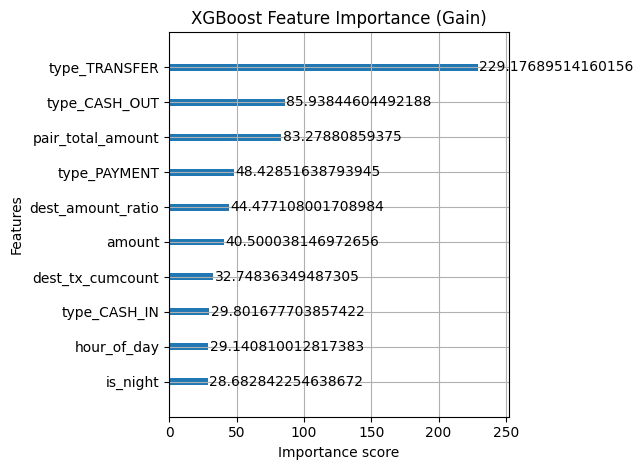

In [6]:
import matplotlib.pyplot as plt 
xgb.plot_importance(model, importance_type='gain', max_num_features=10, title="XGBoost Feature Importance (Gain)")

# 2. Make the layout tight so it looks good in a PowerPoint
plt.tight_layout()

# 3. Save it as a high-res image to drop into your presentation
plt.savefig("feature_importance_for_slides.png", dpi=300)
plt.show()

In [ ]:
['amount' 'type_CASH_IN' 'type_CASH_OUT' 'type_DEBIT' 'type_PAYMENT'
 'type_TRANSFER' 'orig_tx_count_same_step' 'orig_tx_cumcount'
 'orig_prev_amount' 'orig_amount_ratio' 'steps_since_last_tx'
 'dest_tx_cumcount' 'dest_prev_amount' 'dest_amount_ratio'
 'dest_steps_since_last' 'pair_tx_cumcount' 'is_new_dest'
 'pair_total_amount' 'hour_of_day' 'day' 'is_night']